In [1]:
import numpy as np
import pandas as pd
import plotly.express as px

In [2]:
df = px.data.iris().drop('species_id', axis= 1)
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [3]:
df.shape

(150, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [6]:
df.duplicated().sum()

3

In [7]:
x = df.drop('species', axis= 1)
y = df['species']

In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42, stratify= y)

In [9]:
x_train.head()

,sepal_length,sepal_width,petal_length,petal_width
8,4.4,2.9,1.4,0.2
106,4.9,2.5,4.5,1.7
76,6.8,2.8,4.8,1.4
9,4.9,3.1,1.5,0.1
89,5.5,2.5,4.0,1.3


In [10]:
y.value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

# DecisionTree

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt = DecisionTreeClassifier(criterion= 'entropy', random_state= 42)

dt.fit(x_train, y_train)

print('\nDT Train :\n', classification_report(y_train, dt.predict(x_train)))
print('\nDT Test :\n', classification_report(y_test, dt.predict(x_test)))


DT Train :
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        40
  versicolor       1.00      1.00      1.00        40
   virginica       1.00      1.00      1.00        40

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120


DT Test :
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt = DecisionTreeClassifier(criterion= 'entropy', random_state= 42, max_depth= 3)

dt.fit(x_train, y_train)

print('\nDT Train :\n', classification_report(y_train, dt.predict(x_train)))
print('\nDT Test :\n', classification_report(y_test, dt.predict(x_test)))


DT Train :
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        40
  versicolor       1.00      0.95      0.97        40
   virginica       0.95      1.00      0.98        40

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120


DT Test :
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [13]:
dt.feature_names_in_

array(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
      dtype=object)

* DecisionTree Map

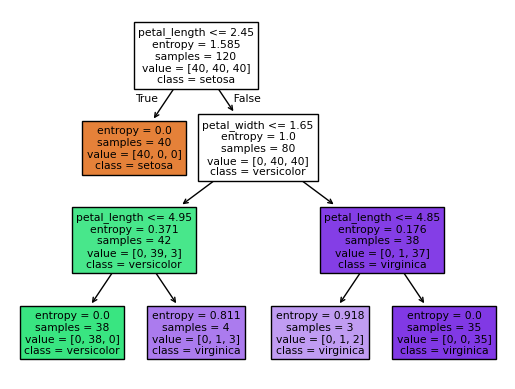

In [14]:
from sklearn.tree import plot_tree

plot_tree(dt, feature_names= dt.feature_names_in_, class_names= y.unique(), filled= True);

In [15]:
dt.feature_importances_

array([0.        , 0.        , 0.68654624, 0.31345376])

In [16]:
px.bar(x = dt.feature_names_in_, y= dt.feature_importances_)

# RandomForest

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state= 42, max_depth= 3)

rf.fit(x_train, y_train)

print('\nrf Train :\n', classification_report(y_train, rf.predict(x_train)))
print('\nrf Test :\n', classification_report(y_test, rf.predict(x_test)))


rf Train :
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        40
  versicolor       1.00      0.95      0.97        40
   virginica       0.95      1.00      0.98        40

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120


rf Test :
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [18]:
rf.feature_importances_

array([0.11430736, 0.00576396, 0.44033779, 0.43959089])

In [19]:
px.bar(x = rf.feature_names_in_, y= rf.feature_importances_)

# xgboost


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [22]:
from xgboost import XGBClassifier

xgb = XGBClassifier(reg_alpha = 1.5)

xgb.fit(x_train, y_train)

print('\nxgb Train :\n', classification_report(y_train, xgb.predict(x_train)))
print('\nxgb Test :\n', classification_report(y_test, xgb.predict(x_test)))


xgb Train :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      0.95      0.97        40
           2       0.95      1.00      0.98        40

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120


xgb Test :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

